<a href="https://colab.research.google.com/github/virenmarcellya12/Analisis-Deret-Waktu/blob/main/Tugas_Kelompok_Minggu_4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# EXPLORASI DATA DERET WAKTU
**DATA = SUHU KOTA BANDUNG**

**KELOMPOK 4**

Haniyathul Husna M0501251011

Siti Zakiah M0501251044

Viren Marcellya Clarenda Siboro M0501251047


In [ ]:
#Install terlebih dahulu package PythonTsa
!pip install PythonTsa

# menginstall package pydataset
!pip install pydataset
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
from PythonTsa.plot_acf_pacf import acf_pacf_fig
from pydataset import data
from statsmodels.datasets import get_rdataset

import warnings
warnings.filterwarnings("ignore")

## Data Suhu di Kota Bandung

Analisis ini menggunakan data sekunder mengenai rata-rata suhu udara bulanan di Kota Bandung. Data ini merupakan data deret waktu (time series) dengan rentang waktu pengamatan selama 21 tahun, terhitung mulai dari 1 Januari 2005 hingga 1 Desember 2025. Variable suhu diukur dalam unit Derajat Celsius (°C)

In [ ]:
suhu = pd.read_excel(
    'https://raw.githubusercontent.com/haniyathul/Praktikum-Analisis-Deret-Waktu/refs/heads/main/suhu_di_kota_bandung.xlsx')

# Tampilkan 5 baris pertama
suhu.head()

,suhu,tahun
0,24.2,2005-01-01
1,23.0,2005-02-01
2,23.3,2005-03-01
3,23.6,2005-04-01
4,23.9,2005-05-01


In [ ]:
suhu.describe()

,suhu,tahun
count,252.000000,252
mean,24.709603,2015-06-16 20:11:25.714285824
min,15.400000,2005-01-01 00:00:00
25%,20.200000,2010-03-24 06:00:00
50%,23.850000,2015-06-16 00:00:00
75%,29.700000,2020-09-08 12:00:00
max,36.000000,2025-12-01 00:00:00
std,5.043741,NaN


Jumlah Pengamatan: Data terdiri dari 252 observasi bulanan yang tercatat dari rentang Januari 2005 hingga Desember 2025.

Nilai Rata-rata & Sebaran: Rata-rata suhu Kota Bandung selama periode pengamatan berada di angka 24.71°C dengan standar deviasi sebesar 5.04°C, menunjukkan fluktuasi suhu yang relatif bervariasi.

Rentang Suhu (Ekstrem): Suhu udara terendah (minimum) yang tercatat adalah 15.40°C (pada 1 Januari 2005), sedangkan suhu udara tertinggi (maksimum) mencapai 36.00°C (pada 1 Desember 2025).

Kuartil (Karakteristik Distribusi):

25% (Q1): Sebesar 25% dari total rentang waktu pengamatan memiliki suhu di bawah 20.20°C.

50% (Median): Nilai tengah suhu berada di angka 23.85°C.

75% (Q3): Sebesar 75% dari total rentang waktu pengamatan memiliki suhu di bawah 29.70°C.

### struktur data

In [ ]:
suhu.dtypes

,0
suhu,float64
tahun,datetime64[ns]


Data ini memuat rata-rata suhu udara bulanan Kota Bandung berskala rasio (derajat Celsius) dengan rentang waktu Januari 2005 hingga Desember 2025 (252 observasi).

suhu: Tipe data float64 (numerik kontinu).

tahun: Tipe data datetime64[ns] (format tanggal yang sudah sesuai untuk analisis time series).

In [ ]:
suhu.head()

,suhu,tahun
0,24.2,2005-01-01
1,23.0,2005-02-01
2,23.3,2005-03-01
3,23.6,2005-04-01
4,23.9,2005-05-01


suhu.head() menampilkan 5 amatan pertama

In [ ]:
suhu.tail()

,suhu,tahun
247,33.4,2025-08-01
248,32.2,2025-09-01
249,36.0,2025-10-01
250,33.0,2025-11-01
251,32.8,2025-12-01


suhu.tail() menampilkan 5 amatan terakhir

In [ ]:
suhu.isnull().sum()

,0
suhu,0
tahun,0


Pemeriksaan Nilai Hilang (Missing Value)

Hasil pengecekan menunjukkan angka 0 pada kolom suhu maupun tahun, yang menandakan bahwa data suhu Kota Bandung bersih dan lengkap tanpa ada nilai yang hilang (missing value). Dengan demikian, seluruh 252 observasi dapat langsung digunakan untuk tahapan analisis selanjutnya tanpa memerlukan proses imputasi data.

## Pengecekan Outlier

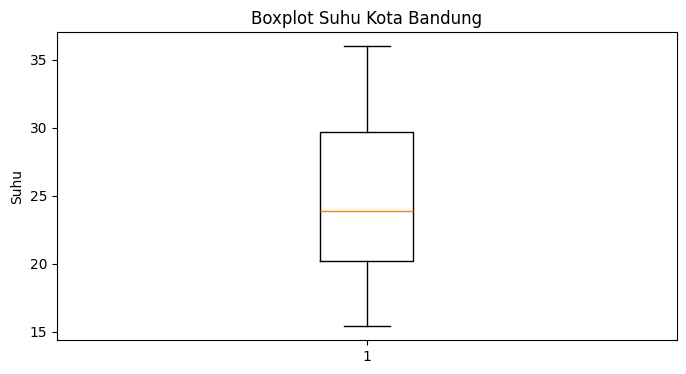

In [ ]:
#cek outlier
plt.figure(figsize=(8,4))

plt.boxplot(suhu["suhu"].dropna())

plt.ylabel("Suhu")
plt.title("Boxplot Suhu Kota Bandung")

plt.show()

**Interpretasi:**

Berdasarkan hasil Boxplot menunjukkan rata-rata tengah (median) suhu Kota Bandung berada pada 24°C, dengan sebaran data cukup lebar antara 20°C (Q1) hingga 30°C (Q3). Suhu berfluktuasi dari 15,4°C hingga 36°C tanpa terdeteksi adanya pencilan (outlier). Jarak median ke Q3 yang lebih panjang menunjukkan distribusi data sedikit menjulur ke kanan (positively skewed).

## plot data suhu

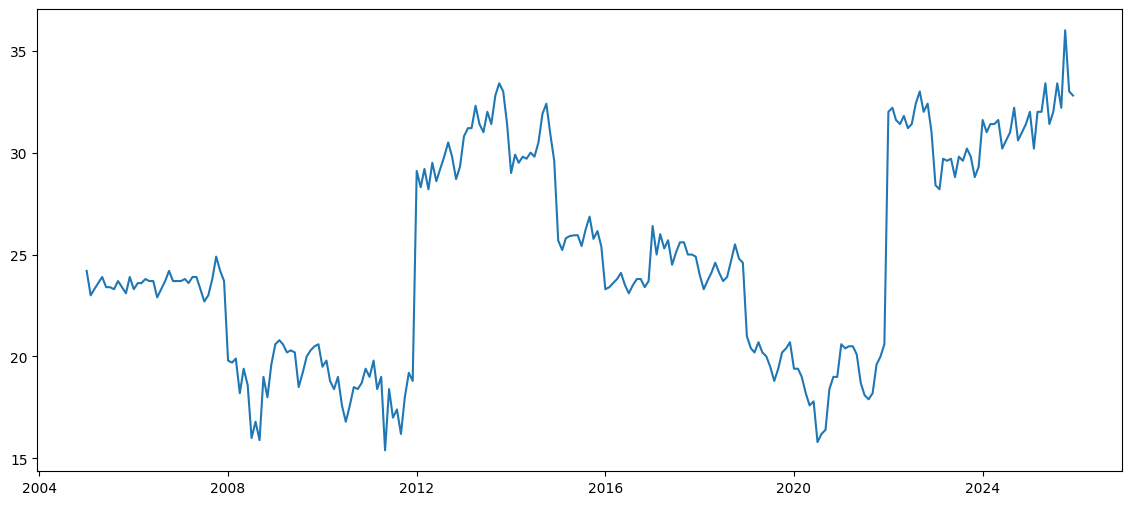

In [ ]:
plt.figure(figsize=(14,6))
plt.plot(suhu['tahun'],suhu['suhu']); plt.show()

**Interpretasi:**

Berdasarkan plot deret waktu suhu Kota Bandung, terlihat bahwa suhu mengalami fluktuasi yang cukup besar dari waktu ke waktu dan belum menunjukkan pola tren yang konsisten. Pada periode 2004–2007, suhu relatif stabil pada kisaran 23–24°C. Kemudian terjadi penurunan pada sekitar 2008–2011 dengan suhu berada pada kisaran 16–20°C. Setelah itu, suhu meningkat cukup tajam pada sekitar 2012 hingga mencapai kisaran 29–33°C. Pada periode 2015–2022, suhu kembali mengalami penurunan dan berfluktuasi pada kisaran 18–26°C. Selanjutnya, sejak sekitar 2022 terjadi kenaikan level suhu yang cukup jelas hingga mencapai kisaran 30–36°C pada periode 2023–2026. Secara keseluruhan, plot menunjukkan adanya fluktuasi suhu yang cukup kuat antarperiode. Kondisi tersebut mengindikasikan bahwa karakteristik rata-rata data kemungkinan berubah sepanjang waktu, sehingga stasioneritas data perlu dikonfirmasi lebih lanjut menggunakan uji statistik seperti Augmented Dickey-Fuller (ADF).

## plot ACF dan PACF

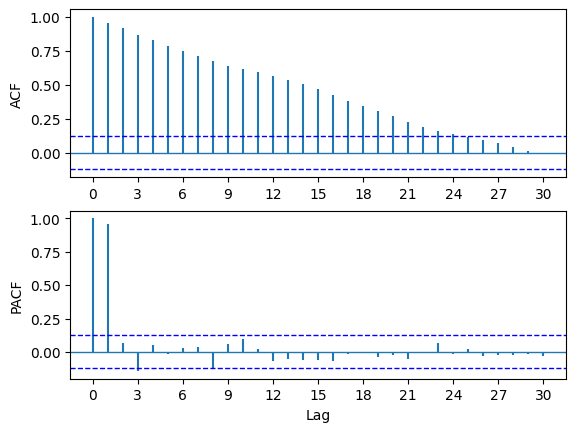

In [ ]:
acf_pacf_fig(suhu['suhu'], both=True, lag=30)

**Interpretasi:**

Berdasarkan plot ACF, terlihat bahwa nilai autokorelasi pada lag awal sangat tinggi, yaitu mendekati 1, kemudian menurun secara perlahan seiring bertambahnya lag. Pola penurunan yang lambat ini menunjukkan bahwa nilai suhu pada suatu waktu memiliki hubungan yang cukup kuat dengan nilai suhu pada beberapa periode sebelumnya.

Sementara itu, pada plot PACF terlihat satu spike yang sangat tinggi pada lag 1, sedangkan sebagian besar lag berikutnya berada di dalam batas interval kepercayaan. Pola tersebut menunjukkan adanya ketergantungan kuat pada lag pertama dan mengindikasikan bahwa komponen autoregressive (AR) orde rendah, khususnya AR(1), dapat dipertimbangkan.

## Cek Stasioner Data Suhu

### Uji ADF (kestasioneran dalam nilai tengah)
Hipotesis yang digunakan dalam uji ADF adalah


$H_0$ menyatakan deret tidak stasioner

$H_1$ menyatakan deret stasioner.

Kriteria keputusan: Tolak $H_0$ jika p-value < 0.05

In [ ]:
# uji unit-root Augmented Dickey Fuller
from statsmodels.tsa.stattools import adfuller

adfuller(suhu['suhu'])[1]

0.2820770094308047

Berdasarkan hasil uji ADF diperoleh p-value sebesar 0,2821. Karena p-value > 0,05, maka gagal tolak H0. Artinya, deret suhu belum stasioner dalam nilai tengah, sehingga perlu dilakukan differencing untuk memperoleh deret yang lebih stasioner.

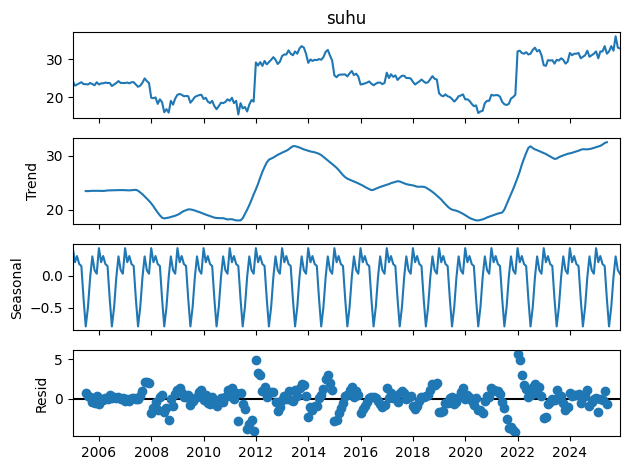

In [ ]:
from statsmodels.tsa.seasonal import seasonal_decompose
suhu2=suhu.set_index('tahun')
result = seasonal_decompose(suhu2['suhu'], model='additive')
result.plot()
plt.show()

**Interpretasi :**

Berdasarkan plot dekomposisi, deret suhu menunjukkan adanya perubahan pola yang cukup jelas dari waktu ke waktu. Komponen trend bergerak naik dan turun dalam jangka panjang, sehingga rata-rata deret belum stabil. Hal ini sejalan dengan hasil uji ADF sebelumnya yang menunjukkan bahwa deret suhu belum stasioner dalam nilai tengah.

Komponen seasonal menunjukkan pola yang berulang secara teratur dengan bentuk dan besar fluktuasi yang relatif sama pada setiap periode, sehingga terdapat pola musiman yang cukup konsisten. Sementara pada komponen residual sebagian besar berfluktuasi di sekitar nol, walaupun masih terdapat beberapa nilai yang cukup besar pada periode tertentu. Secara umum, perubahan deret suhu dipengaruhi oleh komponen tren dan musiman, sedangkan variasi lain yang tidak dapat dijelaskan oleh kedua komponen tersebut terdapat pada residual.


### Uji boxcox (kestasioneran dalan ragam)

Pada tahap ini dilakukan uji stasioneritas dalam ragam (varians) menggunakan transformasi Box-Cox pada variabel suhu.

In [ ]:
from scipy.stats import boxcox,  boxcox_llf
data,lambda_fit,ci=boxcox(suhu['suhu'], alpha=0.05)

print(f'nilai lambda: ',lambda_fit)
print(f'interval kepercayaan lambda:', ci)

nilai lambda:  0.3339257369323398
interval kepercayaan lambda: (-0.318672205692964, 0.995352589824295)


Secara statistik, pengujian kestasioneran dalam ragam menggunakan dasar hipotesis berikut:

$H_0: \lambda = 1$ (Ragam stasioner / homogen, tidak perlu transformasi).

$H_1: \lambda \neq 1$ (Ragam tidak stasioner / heterogen, perlu transformasi Box-Cox).

Kesimpulan: Secara statistik, ragam data tidak stasioner.

## Transformasi Boxcox

Pada tahap ini dilakukan proses transformasi untuk menstabilkan niali ragam pada deret waktu.

In [ ]:
suhu['suhu_boxcox'], fitted_lambda = boxcox(suhu['suhu'])
print(f"Lambda optimal: {fitted_lambda}")

Lambda optimal: 0.3339257369323398


Berdasarkan hasil transformasi Box-Cox, diperoleh nilai lambda optimal sebesar **0,334**. Nilai tersebut cukup jauh dari 1, sehingga data disarankan untuk ditransformasi agar variansnya lebih stabil. Nilai lambda yang mendekati \(1/3\) menunjukkan bahwa bentuk transformasi yang digunakan kurang lebih mendekati transformasi akar pangkat tiga. Setelah transformasi Box-Cox dilakukan, data selanjutnya dapat diperiksa kembali kestabilan variansnya sebelum dilanjutkan ke tahap differencing dan pemodelan.


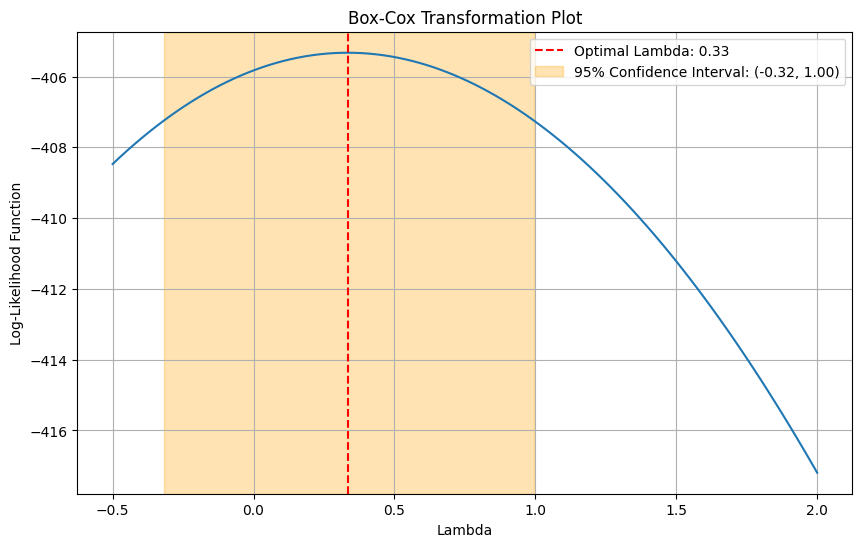

In [ ]:
# Generate a range of lambda values
import numpy as np
import matplotlib.pyplot as plt

lambdas = np.linspace(-0.5, 2, 100)

# Calculate log-likelihood for each lambda
llf = [boxcox_llf(l, suhu['suhu']) for l in lambdas]

plt.figure(figsize=(10, 6))
plt.plot(lambdas, llf)
plt.axvline(lambda_fit, color='r', linestyle='--', label=f'Optimal Lambda: {lambda_fit:.2f}')
plt.axvspan(ci[0], ci[1], color='orange', alpha=0.3, label=f'95% Confidence Interval: ({ci[0]:.2f}, {ci[1]:.2f})')
plt.xlabel('Lambda')
plt.ylabel('Log-Likelihood Function')
plt.title('Box-Cox Transformation Plot')
plt.legend(); plt.grid(True); plt.show()

**Interpretasi :**

 untuk memvisualisasikan fungsi Log-Likelihood terhadap berbagai kemungkinan nilai $\lambda$ pada rentang $-0.5$ hingga $2.0$. Grafik Box-Cox Transformation Plot memperlihatkan bentuk kurva parabola terbalik.

 Garis Putus-Putus Merah: Menunjukkan titik puncak kurva fungsi Log-Likelihood yang berada tepat pada $\lambda = 0.33$.

 Titik puncak ini mewakili nilai $\lambda$ terbaik yang memaksimumkan fungsi likuiditas data.

 Area Arsiran Oranye: Menggambarkan wilayah interval kepercayaan 95% untuk $\lambda$, yaitu dari $-0.32$ hingga $1.00$. Rentang ini memberikan batasan nilai $\lambda$ yang masih dapat diterima secara statistik untuk mentransformasi data.

 Plot ini mengonfirmasi bahwa nilai $\lambda = 0.33$ adalah pilihan terbaik untuk mentransformasi variabel suhu agar asumsi kestasioneran dalam ragam dapat terpenuhi secara optimal.

In [ ]:
# Evaluasi Kestasioneran Ragam Pasca-Transformasi
data,lambda_fit,ci=boxcox(suhu['suhu_boxcox'], alpha=0.05)

print(f'nilai lambda: ',lambda_fit)

nilai lambda:  0.919836371771979


Setelah transformasi Box-Cox diterapkan pada variabel suhu (menghasilkan variabel suhu_boxcox), dilakukan pengujian ulang nilai $\lambda$ pada data baru tersebut.

Hasil evaluasi menunjukkan nilai $\lambda$ baru sebesar $0.92$ ($\approx 1$).Karena nilai $\lambda$ yang dihasilkan sudah mendekati angka $1$, hal ini membuktikan bahwa ragam data sudah stasioner secara statistik dan proses transformasi Box-Cox telah berhasil menstabilkan varians data.

## Differensing

Pada tahap ini dilakukan proses differencing orde pertama ($d=1$) terhadap variabel suhu_boxcox untuk menghilangkan pola tren dan menstabilkan rata-rata (mean) deret waktu.

In [ ]:
# Differencing pada data hasil Box-Cox (d=1)
suhu['boxcox_diff1'] = suhu['suhu_boxcox'].diff(1)
suhu['boxcox_diff1']

,boxcox_diff1
0,NaN
1,-0.146141
2,0.037003
3,0.036687
4,0.036377
...,...
247,0.137203
248,-0.117361
249,0.362331
250,-0.283773


Proses differencing menghitung selisih antara nilai pada periode saat ini ($t$) dengan periode sebelumnya ($t-1$). Hal ini menyebabkan baris pertama (indeks 0) bernilai NaN (Not a Number) karena tidak memiliki nilai pembanding sebelumnya. Jumlah data efektif yang dianalisis menjadi 251 observasi.  

Perubahan Skala Nilai: Hasil penolakan tren menghasilkan nilai selisih yang berfluktuasi positif dan negatif di sekitar angka nol, seperti $-0.1461$, $0.0370$, hingga $-0.0195$ pada periode akhir.

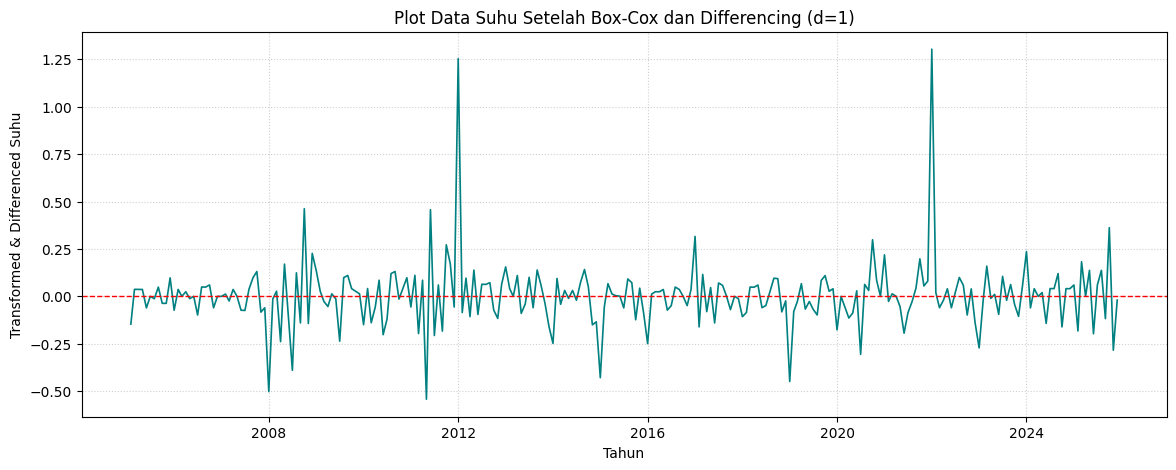

In [ ]:
import matplotlib.pyplot as plt

# Plot Data Setelah Box-Cox + Differencing
plt.figure(figsize=(14, 5))
plt.plot(suhu['tahun'][1:], suhu['boxcox_diff1'].dropna(), color='teal', linewidth=1.2)
plt.axhline(0, color='red', linestyle='--', linewidth=1)
plt.title('Plot Data Suhu Setelah Box-Cox dan Differencing (d=1)')
plt.xlabel('Tahun')
plt.ylabel('Transformed & Differenced Suhu')
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()

**Interpretasi:**

Plot ini memvisualisasikan data deret waktu yang telah melalui tahapan transformasi Box-Cox dan differencing orde 1.  Kestasioneran Rata-Rata: Pergerakan garis tebal (teal) kini berfluktuasi secara konsisten di sekitar garis horizontal merah ($y=0$).

Pola tren naik atau turun yang sebelumnya terlihat pada data asli telah sepenuhnya tereliminasi.  

Kestasioneran Ragam: Lebar ampltudo fluktuasi data relatif seragam dari tahun 2005 hingga 2025, mengonfirmasi bahwa varians data telah stabil.  

Berdasarkan plot deret waktu ini, data suhu Kota Bandung teridentifikasi sudah stasioner secara visual, baik dalam rata-rata maupun varians, sehingga memenuhi syarat untuk dilanjutkan ke tahap identifikasi orde model ARIMA.

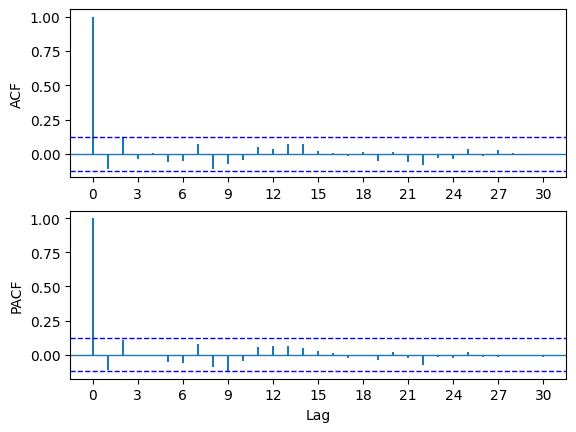

In [ ]:
# Cek ulang ACF & PACF
acf_pacf_fig(suhu['boxcox_diff1'].dropna(), both=True, lag=30)

**Interpretasi:**

Berdasarkan plot ACF dan PACF setelah dilakukan differencing orde pertama, terlihat bahwa hampir seluruh nilai autokorelasi dan autokorelasi parsial berada di dalam batas interval kepercayaan dan cenderung berada di sekitar nol. Tidak terlihat pola autokorelasi yang kuat maupun pola musiman yang jelas pada lag tertentu. Hal ini menunjukkan bahwa differencing orde pertama telah mampu mengurangi ketidakstasioneran pada deret dan deret hasil differencing sudah lebih stabil.

In [ ]:
from scipy.stats import boxcox
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.arima.model import ARIMA

# Transformasi Box-Cox pada data asli
suhu['suhu_boxcox'], fitted_lambda = boxcox(suhu['suhu'])

# Buat kolom boxcox_diff1
suhu['boxcox_diff1'] = suhu['suhu_boxcox'].diff(1)

# Uji ADF Stasioneritas
adf_test = adfuller(suhu['boxcox_diff1'].dropna())
print(f"ADF Statistic : {adf_test[0]:.4f}")
print(f"p-value       : {adf_test[1]:.4e}")

ADF Statistic : -10.4224
p-value       : 1.6909e-18


Berdasarkan hasil uji ADF setelah transformasi Box-Cox dan differencing orde pertama, diperoleh ADF Statistic sebesar $-10.4224$ dengan p-value sebesar $1.6909 \times 10^{-18}$. Karena p-value < 0,05, maka $H_0$ ditolak. Artinya, deret sudah stasioner dalam nilai tengah sehingga tidak diperlukan differencing tambahan.